# Comparing Sentiment Analysis Approaches: BERT vs. SVM

In [1]:
# Imports for visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 14
})

In [3]:
# Metrics from BERT model
bert_metrics = {
    'error_rate': 0.17,
    'accuracy': 0.83,
    'class_metrics': {
        'negative': {'precision': 0.71, 'recall': 0.83, 'f1-score': 0.77, 'support': 6},
        'neutral': {'precision': 1.00, 'recall': 0.67, 'f1-score': 0.80, 'support': 6},
        'positive': {'precision': 0.86, 'recall': 1.00, 'f1-score': 0.92, 'support': 6}
    },
    'macro_avg': {'precision': 0.86, 'recall': 0.83, 'f1-score': 0.83, 'support': 18},
    'weighted_avg': {'precision': 0.86, 'recall': 0.83, 'f1-score': 0.83, 'support': 18}
}

# Metrics from SVM model
svm_metrics = {
    'error_rate': 0.28,
    'accuracy': 0.72,
    'class_metrics': {
        'negative': {'precision': 0.55, 'recall': 1.00, 'f1-score': 0.71, 'support': 6},
        'neutral': {'precision': 1.00, 'recall': 0.50, 'f1-score': 0.67, 'support': 6},
        'positive': {'precision': 1.00, 'recall': 0.67, 'f1-score': 0.80, 'support': 6}
    },
    'macro_avg': {'precision': 0.85, 'recall': 0.72, 'f1-score': 0.72, 'support': 18},
    'weighted_avg': {'precision': 0.85, 'recall': 0.72, 'f1-score': 0.72, 'support': 18}
}

### Comparison plot #1: Per-Class Performance Comparison Bar Chart

/var/folders/ll/w37f_r8j6pxb28fvqbt5q_lc0000gn/T/ipykernel_9374/2056779150.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


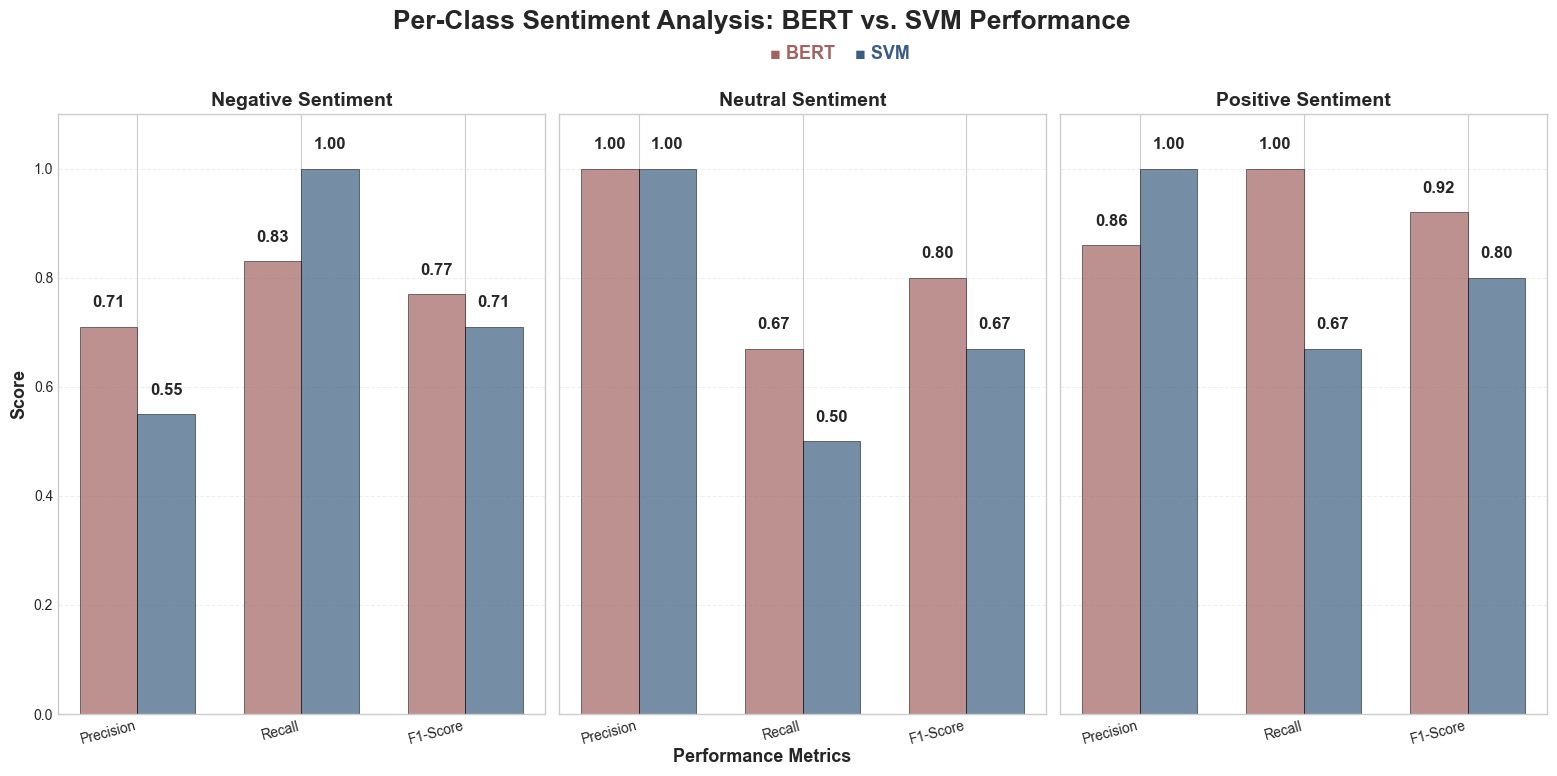

In [4]:
def bar_chart(bert_metrics, svm_metrics):

    classes = ['Negative', 'Neutral', 'Positive']
    metrics = ['Precision', 'Recall', 'F1-Score']
    fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)
    
    bert_color = '#A26360'  
    svm_color = '#3C5D81'   
    
    # Plot for each sentiment class
    for i, sentiment_class in enumerate(classes):
        ax = axes[i]
        
        bert_values = [
            bert_metrics['class_metrics'][sentiment_class.lower()]['precision'],
            bert_metrics['class_metrics'][sentiment_class.lower()]['recall'],
            bert_metrics['class_metrics'][sentiment_class.lower()]['f1-score']
        ]
        
        svm_values = [
            svm_metrics['class_metrics'][sentiment_class.lower()]['precision'],
            svm_metrics['class_metrics'][sentiment_class.lower()]['recall'],
            svm_metrics['class_metrics'][sentiment_class.lower()]['f1-score']
        ]
        
        x = np.arange(len(metrics))
        width = 0.35

        bert_bars = ax.bar(x - width/2, bert_values, width, 
                           color=bert_color, alpha=0.7, 
                           edgecolor='black', linewidth=0.5)
        
        svm_bars = ax.bar(x + width/2, svm_values, width, 
                          color=svm_color, alpha=0.7, 
                          edgecolor='black', linewidth=0.5)
        
        def add_value_annotations(bars):
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                        f'{height:.2f}', 
                        ha='center', va='bottom', fontsize=12, 
                        fontweight='bold')
        
        add_value_annotations(bert_bars)
        add_value_annotations(svm_bars)
        
        ax.set_title(f'{sentiment_class} Sentiment', fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(metrics, rotation=15, ha='right')

        ax.set_ylim(0, 1.1)
        ax.set_yticks(np.linspace(0, 1, 6))

        ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    fig.suptitle('Per-Class Sentiment Analysis: BERT vs. SVM Performance', 
                 fontweight='bold', fontsize=19, y=0.98)
    
    legend_ax = fig.add_axes([0.5, 0.92, 0.1, 0.01], frameon=False)
    legend_ax.axis('off')
    legend_ax.text(0.25, 0.5, '■ BERT', color=bert_color, fontweight='bold', fontsize=13, va='center', ha='center')
    legend_ax.text(0.75, 0.5, '■ SVM', color=svm_color, fontweight='bold', fontsize=13, va='center', ha='center')
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85, bottom=0.1, left=0.06)
    
    fig.text(0.03, 0.5, 'Score', va='center', rotation='vertical', fontweight='bold', fontsize=13)
    fig.text(0.5, 0.04, 'Performance Metrics', ha='center', fontweight='bold', fontsize=13)
    
    return plt

# Generate and display the plot
comparison_plot = bar_chart(bert_metrics, svm_metrics)
comparison_plot.show()

### Comparison plot #2:Aggregated Performance Comparison

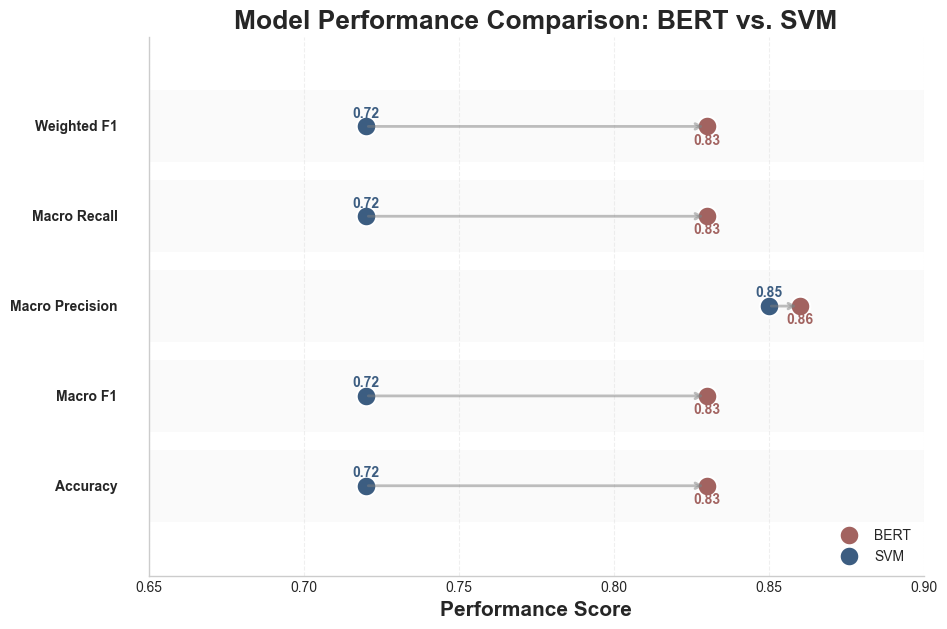

In [5]:
def plot_dumbbell(bert_metrics, svm_metrics):
    metrics = [
        ('Accuracy', bert_metrics['accuracy'], svm_metrics['accuracy']),
        ('Macro F1', bert_metrics['macro_avg']['f1-score'], svm_metrics['macro_avg']['f1-score']),
        ('Macro Precision', bert_metrics['macro_avg']['precision'], svm_metrics['macro_avg']['precision']),
        ('Macro Recall', bert_metrics['macro_avg']['recall'], svm_metrics['macro_avg']['recall']),
        ('Weighted F1', bert_metrics['weighted_avg']['f1-score'], svm_metrics['weighted_avg']['f1-score'])
    ]
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    bert_color = '#A26360'  
    svm_color = '#3C5D81'

    for i, (metric, bert_val, svm_val) in enumerate(metrics):
        ax.axhspan(i-0.4, i+0.4, facecolor='lightgray', alpha=0.1)
        
        ax.scatter(bert_val, i, color=bert_color, s=200, 
                   edgecolor='white', linewidth=1.5, 
                   label='BERT' if i == 0 else "")
        
        ax.scatter(svm_val, i, color=svm_color, s=200, 
                   edgecolor='white', linewidth=1.5,
                   label='SVM' if i == 0 else "")
        
        ax.text(0.64, i, metric, ha='right', va='center', 
                fontweight='bold', fontsize=10)
        
        ax.text(bert_val, i-0.15, f'{bert_val:.2f}', ha='center', va='center', 
                color=bert_color, fontweight='bold', fontsize=10)
        ax.text(svm_val, i+0.15, f'{svm_val:.2f}', ha='center', va='center', 
                color=svm_color, fontweight='bold', fontsize=10)
        
        # Directional arrow to show performance difference (grey)
        if bert_val > svm_val:
            ax.annotate('', xy=(bert_val, i), xytext=(svm_val, i), 
                        arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=2))
        else:
            ax.annotate('', xy=(svm_val, i), xytext=(bert_val, i), 
                        arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=2))
    ax.set_ylim(-1, len(metrics))
    ax.set_xlim(0.65, 0.90)
    ax.set_yticks([])
    ax.set_xlabel('Performance Score', fontweight='bold', fontsize=15)
    ax.set_title('Model Performance Comparison: BERT vs. SVM', fontweight='bold', fontsize=19)
    
    ax.legend(loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    return plt

# Generate and display the plot
performance_dumbbell = plot_dumbbell(bert_metrics, svm_metrics)
performance_dumbbell.show()